# Pre-ET High-Shear Storm State: Combined Figure

A single 2x2 figure (unlike `decile_composite_figure.ipynb`'s separate per-basin
5-panel grids) comparing North Atlantic and West Pacific directly.

## Paths

See the repo README ("Setting IBTRACS_PATH / IKE_OUTPUT_DIR")
for why these are set here rather than relying on a shell-level `export`.

In [1]:
import os
os.environ["IBTRACS_PATH"] = "/home/sydney.e.walters/IBTrACS"
os.environ["SHIPS_PATH"] = "/data/jacob.carstens/SHIPS"
os.environ["IKE_OUTPUT_DIR"] = "/home/sydney.e.walters/IBTrACS_Manuscript_Figures"


## Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ike_climatology import config
from ike_climatology.decile_composite import (
    load_master_dataframe_decile,
    build_decile_composite_long,
)


## Data extraction

Only North Atlantic and West Pacific, matching the source script.

In [3]:
BASINS = ["North Atlantic", "West Pacific"]
LAG_HOURS = 24

master_df = load_master_dataframe_decile(
    basins=BASINS,
    ibtracs_file_map=config.IBTRACS_FILE_MAP,
    ships_file_map=config.SHIPS_FILE_MAP,
    basin_codes=config.IBTRACS_BASIN_CODES,
    ships_base_path=config.SHIPS_BASE_PATH,
    start_year=config.START_YEAR,
    end_year=config.END_YEAR,
    land_interaction_threshold_km=config.LAND_INTERACTION_THRESHOLD_KM,
)

if master_df.empty:
    raise RuntimeError("No processable storm data found -- check IBTRACS_PATH/SHIPS_PATH.")

print(f"Master: {len(master_df):,} obs")


--- Loading Data (2004-2024) ---

--- Loading Data for North Atlantic ---
Processing 380 storms in North Atlantic...
        - Filtered out 2 crossover storms.

--- Loading Data for West Pacific ---
Processing 622 storms in West Pacific...
        - Filtered out 16 crossover storms.

--- Master DataFrame: 14,171 tropical-phase observations ---
Master: 14,171 obs


## Build the combined, multi-basin quartile composite

In [4]:
composite = build_decile_composite_long(
    master_df, BASINS, lag_hours=LAG_HOURS, upper_pct=0.75, lower_pct=0.25,
)


## Figure

Basin on the x-axis, Upper/Lower quartile as hue, one panel per predictor. Sample sizes
in the x-tick labels are computed per-panel (after that predictor's own NaN drop), so
they vary panel to panel -- e.g. asymmetry trims more rows than Pmin.

/tmp/ipykernel_1106746/2285039472.py:33: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
/tmp/ipykernel_1106746/2285039472.py:33: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
/tmp/ipykernel_1106746/2285039472.py:33: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
/tmp/ipykernel_1106746/2285039472.py:33: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


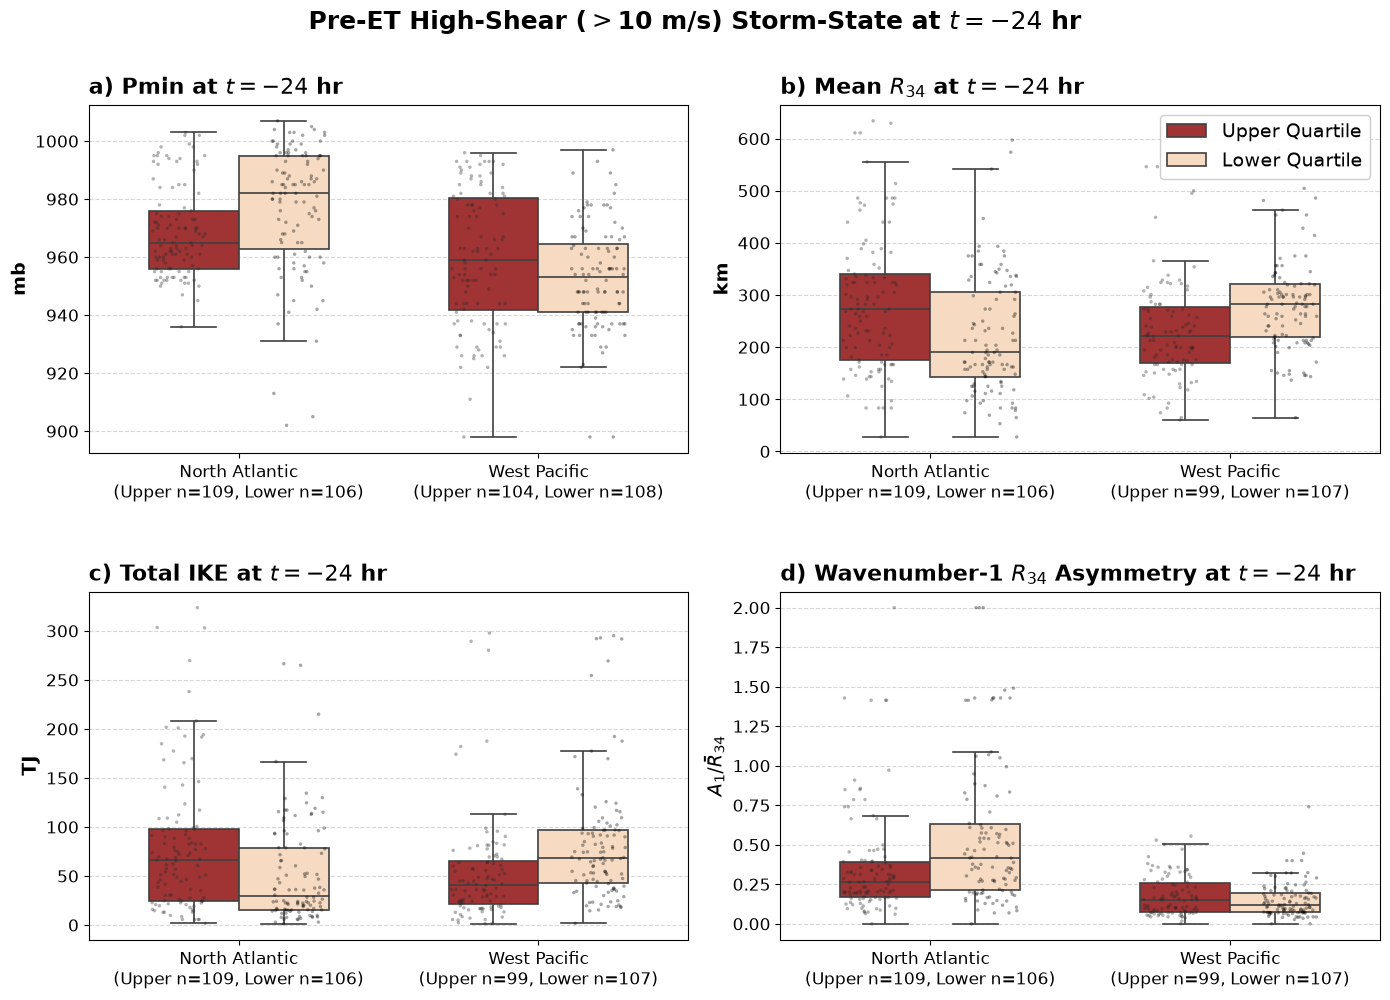

  Plot saved: PreET_DecileComposite_Combined.png
  Underlying data saved: /home/sydney.e.walters/IBTrACS_Manuscript_Figures/PreET_DecileComposite_Combined_data.csv


In [5]:
panel_specs = [
    (f"pmin_mb_lag{LAG_HOURS}",       "Pmin at $t = -24$ hr",          "mb"),
    (f"r34_km_lag{LAG_HOURS}",        "Mean $R_{34}$ at $t = -24$ hr", "km"),
    (f"total_ike_tj_lag{LAG_HOURS}",  "Total IKE at $t = -24$ hr",     "TJ"),
    (f"r34_asymmetry_lag{LAG_HOURS}", "Wavenumber-1 $R_{34}$ Asymmetry at $t = -24$ hr", r"$A_1 / \bar{R}_{34}$"),
]

palette = {"Upper Quartile": "firebrick", "Lower Quartile": "peachpuff"}
group_order = ["Upper Quartile", "Lower Quartile"]
basin_order = ["North Atlantic", "West Pacific"]
panel_letters = ["a)", "b)", "c)", "d)"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (col, label, unit) in enumerate(panel_specs):
    ax = axes[i]
    plot_df = composite[["basin", "group", col]].dropna()

    n_counts = {
        basin: {
            group: len(plot_df[(plot_df["basin"] == basin) & (plot_df["group"] == group)])
            for group in group_order
        }
        for basin in basin_order
    }

    sns.boxplot(
        x="basin", y=col, hue="group", data=plot_df, ax=ax,
        order=basin_order, hue_order=group_order, palette=palette,
        showfliers=False, width=0.6, linewidth=1.2,
    )
    sns.stripplot(
        x="basin", y=col, hue="group", data=plot_df, ax=ax,
        order=basin_order, hue_order=group_order,
        dodge=True, color="black", alpha=0.35, size=2.5, jitter=0.18, legend=False,
    )

    new_xticklabels = [
        f"{basin}\n(Upper n={n_counts[basin]['Upper Quartile']}, Lower n={n_counts[basin]['Lower Quartile']})"
        for basin in basin_order
    ]
    ax.set_xticks(range(len(basin_order)))
    ax.set_xticklabels(new_xticklabels, fontsize=11)

    ax.set_title(f"{panel_letters[i]} {label}", fontsize=16, fontweight="bold", pad=8, loc="left")
    ax.set_xlabel("")
    ax.set_ylabel(unit, fontsize=14, fontweight="bold")
    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)
    ax.grid(True, axis="y", linestyle="--", alpha=0.5)

    if i == 1:
        ax.legend(title="", loc="upper right", fontsize=14, frameon=True, framealpha=0.95)
    else:
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()

fig.suptitle("Pre-ET High-Shear ($>$10 m/s) Storm-State at $t = -24$ hr", fontsize=18, fontweight="bold", y=0.995)
fig.tight_layout()
fig.subplots_adjust(top=0.90, hspace=0.40)

fname = "PreET_DecileComposite_Combined.png"
plt.savefig(os.path.join(config.BASE_OUTPUT_DIR, fname), dpi=300, bbox_inches="tight")
plt.show()
print(f"  Plot saved: {fname}")

composite_path = os.path.join(config.BASE_OUTPUT_DIR, "PreET_DecileComposite_Combined_data.csv")
composite.to_csv(composite_path, index=False)
print(f"  Underlying data saved: {composite_path}")
